# Task 4: Sales Prediction using Python

This notebook performs:
- Data Cleaning
- Data Transformation
- Feature Selection
- Sales Prediction using Linear Regression
- Analysis of Advertising Impact on Sales
- Business Insights


In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
# Load Dataset
df = pd.read_csv('Advertising.csv')

# Display first 5 rows
print(df.head())


   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


In [3]:
# Dataset Information
print(df.info())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None

Missing Values:
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


In [4]:
# Data Cleaning

# Remove unnamed index column if exists
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

print(df.head())


      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9


In [5]:
# Statistical Summary
print(df.describe())


               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000


In [6]:
# Feature Selection

# Features
X = df[['TV', 'Radio', 'Newspaper']]

# Target Variable
y = df['Sales']

print("Features:\n", X.head())
print("\nTarget:\n", y.head())


Features:
       TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target:
 0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64


In [7]:
# Split Dataset into Training and Testing Sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (160, 3)
Testing Data Shape: (40, 3)


In [8]:
# Train Linear Regression Model

model = LinearRegression()
model.fit(X_train, y_train)

print("Model Training Completed")


Model Training Completed


In [9]:
# Model Coefficients

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)

print("\nIntercept:", model.intercept_)


     Feature  Coefficient
0         TV     0.044730
1      Radio     0.189195
2  Newspaper     0.002761

Intercept: 2.979067338122629


In [10]:
# Make Predictions

y_pred = model.predict(X_test)

prediction_df = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

print(prediction_df.head())


   Actual Sales  Predicted Sales
0          16.9        16.408024
1          22.4        20.889882
2          21.4        21.553843
3           7.3        10.608503
4          24.7        22.112373


In [11]:
# Model Evaluation

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE: 1.4607567168117603
MSE: 3.1740973539761033
RMSE: 1.78159966153345
R2 Score: 0.899438024100912


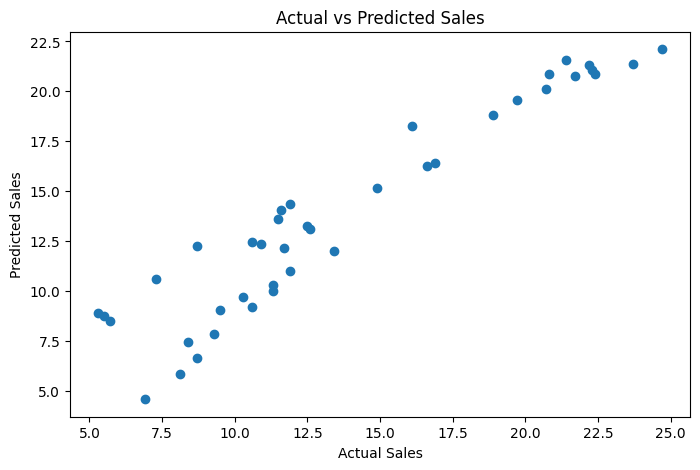

In [12]:
# Visualization: Actual vs Predicted Sales

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()


In [13]:
# Analyze Advertising Impact

impact = pd.DataFrame({
    'Feature': X.columns,
    'Impact': model.coef_
})

impact = impact.sort_values(by='Impact', ascending=False)

print(impact)


     Feature    Impact
1      Radio  0.189195
0         TV  0.044730
2  Newspaper  0.002761


# Business Insights

## Key Findings:
1. TV advertising has the strongest impact on sales.
2. Radio advertising also positively affects sales.
3. Newspaper advertising has lower impact compared to TV and Radio.
4. Increasing advertising budget on high-performing platforms can improve sales forecasting accuracy.

## Conclusion:
The Linear Regression model successfully predicts future sales based on advertising spend. Businesses can use this analysis to optimize marketing strategies and allocate budget more effectively.
